In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
de=pd.read_csv("../DataSets/application_record.csv")
dt=pd.read_csv("../DataSets/credit_record.csv")

In [3]:
df=pd.merge(de,dt,on='ID')

In [4]:
df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0,C
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-1,C
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-2,C
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-3,C
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-4,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777710,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,-9188,-1193,1,0,0,0,Laborers,1.0,-9,0
777711,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,-9188,-1193,1,0,0,0,Laborers,1.0,-10,2
777712,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,-9188,-1193,1,0,0,0,Laborers,1.0,-11,1
777713,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,-9188,-1193,1,0,0,0,Laborers,1.0,-12,0


In [5]:
df.rename(columns={
    'AMT_INCOME_TOTAL': 'Annual_Income',
    'CNT_FAM_MEMBERS': 'Family_Member_Count',
    'DAYS_BIRTH': 'Age_Days',
    'DAYS_EMPLOYED': 'Employment_Days',
    'NAME_INCOME_TYPE': 'Income_Type',
    'OCCUPATION_TYPE': 'Occupation_Type'},inplace=True)
df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,Annual_Income,Income_Type,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,Age_Days,Employment_Days,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,Occupation_Type,Family_Member_Count,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0,C
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-1,C
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-2,C
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-3,C
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-4,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777710,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,-9188,-1193,1,0,0,0,Laborers,1.0,-9,0
777711,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,-9188,-1193,1,0,0,0,Laborers,1.0,-10,2
777712,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,-9188,-1193,1,0,0,0,Laborers,1.0,-11,1
777713,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,-9188,-1193,1,0,0,0,Laborers,1.0,-12,0


In [6]:
df.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
Annual_Income               0
Income_Type                 0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
Age_Days                    0
Employment_Days             0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
Occupation_Type        240048
Family_Member_Count         0
MONTHS_BALANCE              0
STATUS                      0
dtype: int64

In [7]:
df.Occupation_Type.unique()

array([nan, 'Security staff', 'Sales staff', 'Accountants', 'Laborers',
       'Managers', 'Drivers', 'Core staff', 'High skill tech staff',
       'Cleaning staff', 'Private service staff', 'Cooking staff',
       'Low-skill Laborers', 'Medicine staff', 'Secretaries',
       'Waiters/barmen staff', 'HR staff', 'Realty agents', 'IT staff'],
      dtype=object)

In [8]:
df.Occupation_Type.mode()

0    Laborers
Name: Occupation_Type, dtype: object

In [9]:
df.Occupation_Type = df.Occupation_Type.fillna('Laborers')

In [10]:
df.STATUS.unique()

array(['C', '1', '0', 'X', '5', '4', '3', '2'], dtype=object)

In [11]:
df['Credit_Risk'] = df['STATUS']

In [12]:
df.Credit_Risk = df.Credit_Risk.replace(['2','3','4','5'],1)
df.Credit_Risk = df.Credit_Risk.replace(['1','0','C','X'],0)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_28968\3118559122.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.Credit_Risk = df.Credit_Risk.replace(['1','0','C','X'],0)


In [13]:
df.Credit_Risk.unique()

array([0, 1])

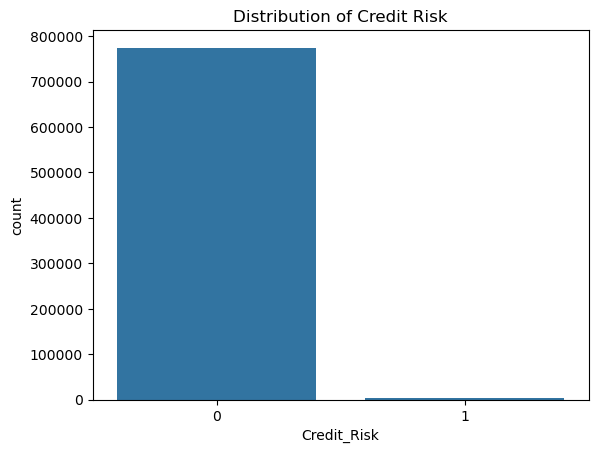

Credit_Risk
0    774887
1      2828
Name: count, dtype: int64

In [14]:
## 1)What is the distribution of the Credit_Risk variable (Good (0) vs Bad (1))?

sb.countplot(x= df.Credit_Risk)
plt.title("Distribution of Credit Risk")
plt.show()
df.Credit_Risk.value_counts()

The dataset is highly imbalanced, with most customers having low credit risk (0) and very few customers having high credit risk (1).

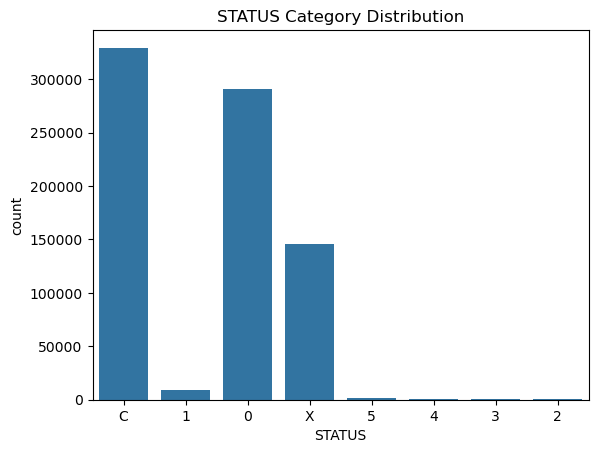

STATUS
C    329536
0    290654
X    145950
1      8747
5      1527
2       801
3       286
4       214
Name: count, dtype: int64

In [15]:
## 2) Which STATUS category occurs most frequently?

sb.countplot(x=df.STATUS)
plt.title("STATUS Category Distribution")
plt.show()
df.STATUS.value_counts()

The `STATUS` distribution shows that most customers fall under categories `C`, `0`, and `X`, while very few customers have delayed payment statuses (`1` to `5`).

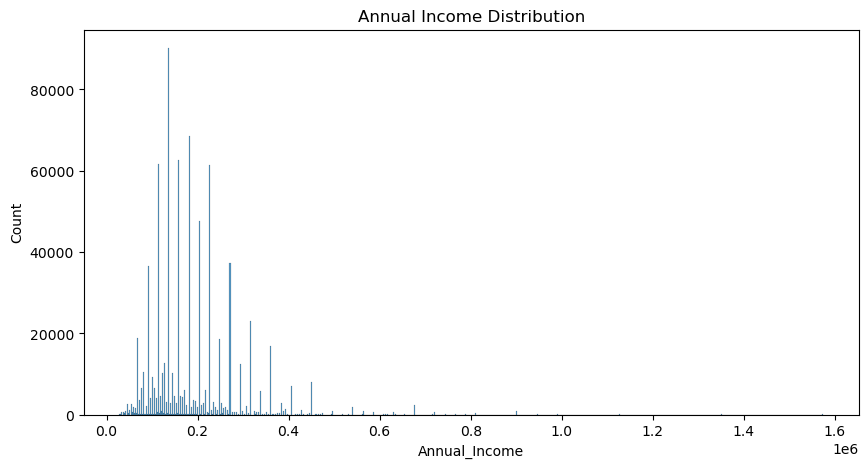

In [16]:
## 3)What is the distribution of Annual Income?

plt.figure(figsize=([10,5]))
sb.histplot(x =df.Annual_Income )
plt.title("Annual Income Distribution")
plt.show()

The histogram shows that most customers have lower to medium annual income, while only a few customers fall into the high-income range.


In [17]:
df['Age_Days'] = abs(df['Age_Days']) // 365
df['Employment_Days'] = abs(df['Employment_Days']) // 365
df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,Annual_Income,Income_Type,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,Employment_Days,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,Occupation_Type,Family_Member_Count,MONTHS_BALANCE,STATUS,Credit_Risk
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,12,1,1,0,0,Laborers,2.0,0,C,0
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,12,1,1,0,0,Laborers,2.0,-1,C,0
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,12,1,1,0,0,Laborers,2.0,-2,C,0
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,12,1,1,0,0,Laborers,2.0,-3,C,0
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,12,1,1,0,0,Laborers,2.0,-4,C,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777710,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,...,3,1,0,0,0,Laborers,1.0,-9,0,0
777711,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,...,3,1,0,0,0,Laborers,1.0,-10,2,1
777712,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,...,3,1,0,0,0,Laborers,1.0,-11,1,0
777713,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,...,3,1,0,0,0,Laborers,1.0,-12,0,0


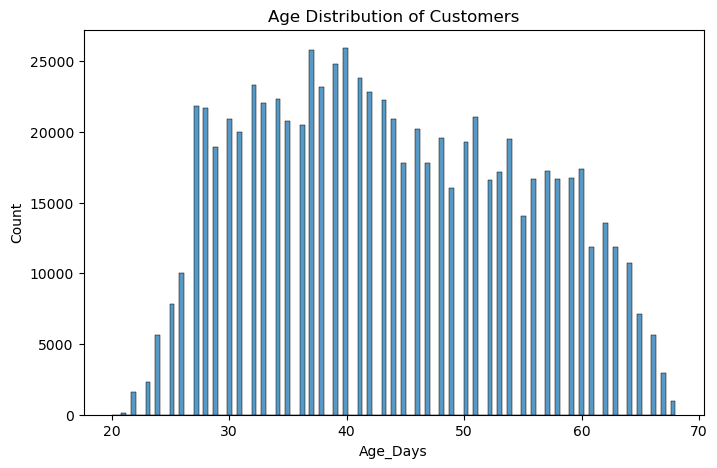

In [18]:
## 4) What is the age distribution of customers?

plt.figure(figsize=[8,5])
sb.histplot(x = df.Age_Days)
plt.title("Age Distribution of Customers")
plt.show()

The age distribution shows that most customers belong to the middle-age group, while fewer customers are very young or very old.

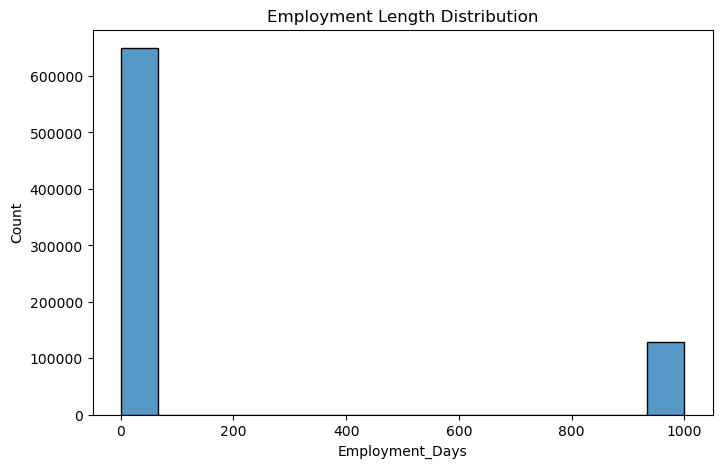

In [51]:
## 5) How is Employment Length distributed?

plt.figure(figsize=[8,5])
sb.histplot(x = df.Employment_Days,bins = 15)
plt.title("Employment Length Distribution")
plt.show()

The distribution indicates that most customers have shorter employment durations, while fewer customers have very long work experience.

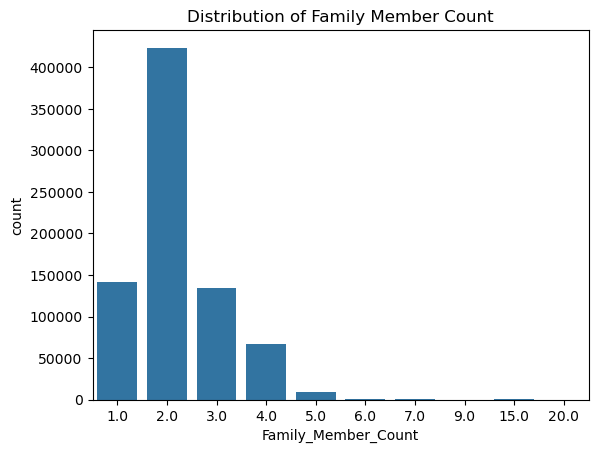

In [20]:
## 6) What is the distribution of Family Member Count?

sb.countplot(x = df.Family_Member_Count)
plt.title('Distribution of Family Member Count')
plt.show()

The countplot shows that most customers have small families with fewer family members, while large families are less common.

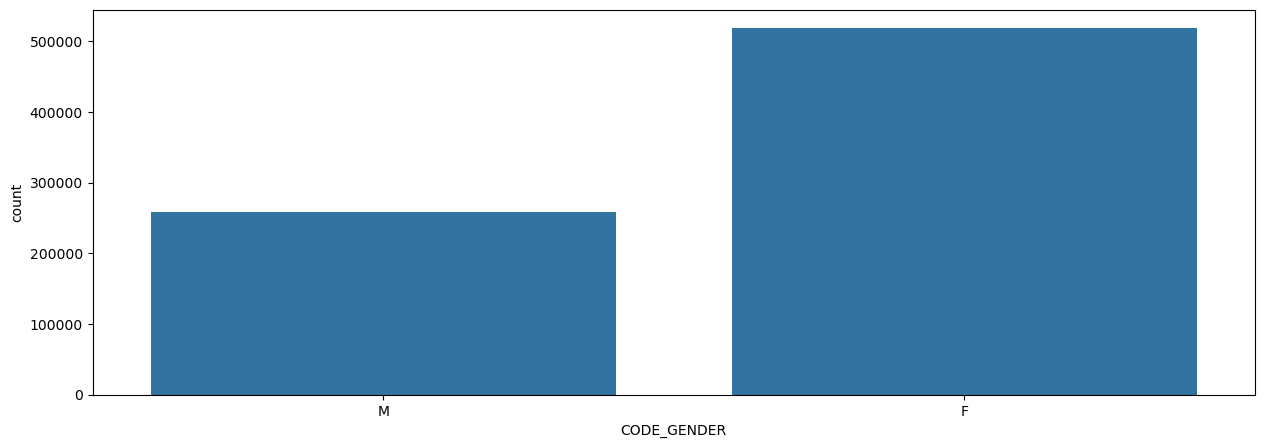

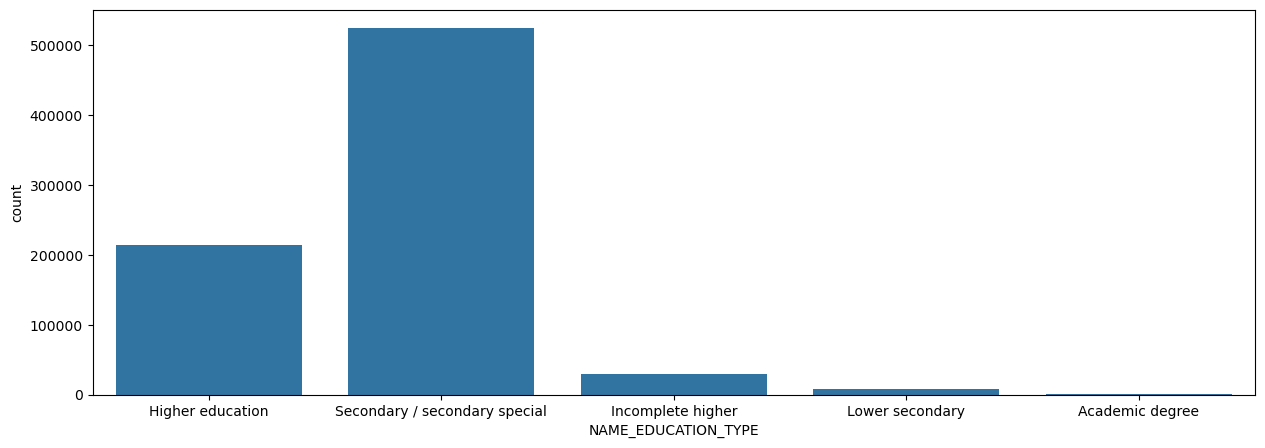

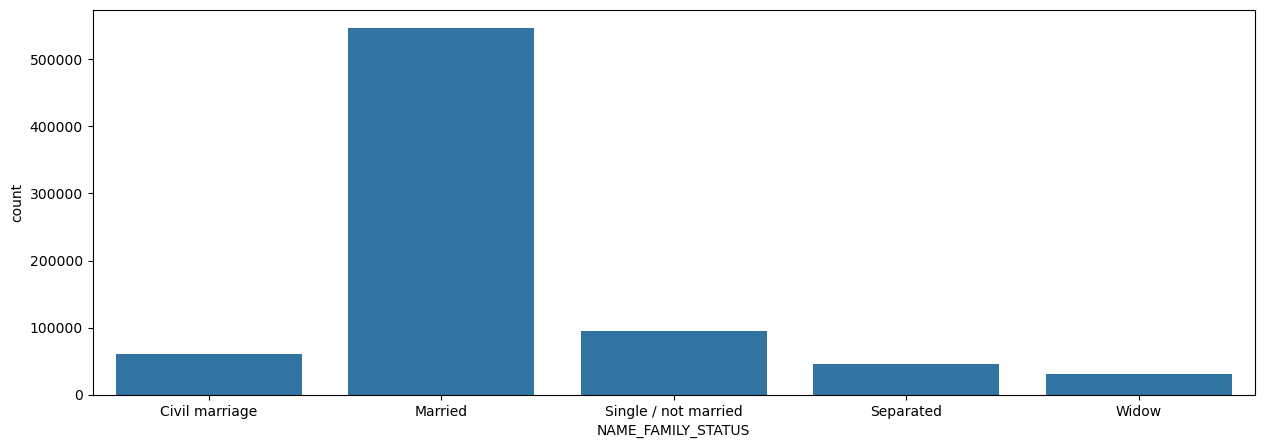

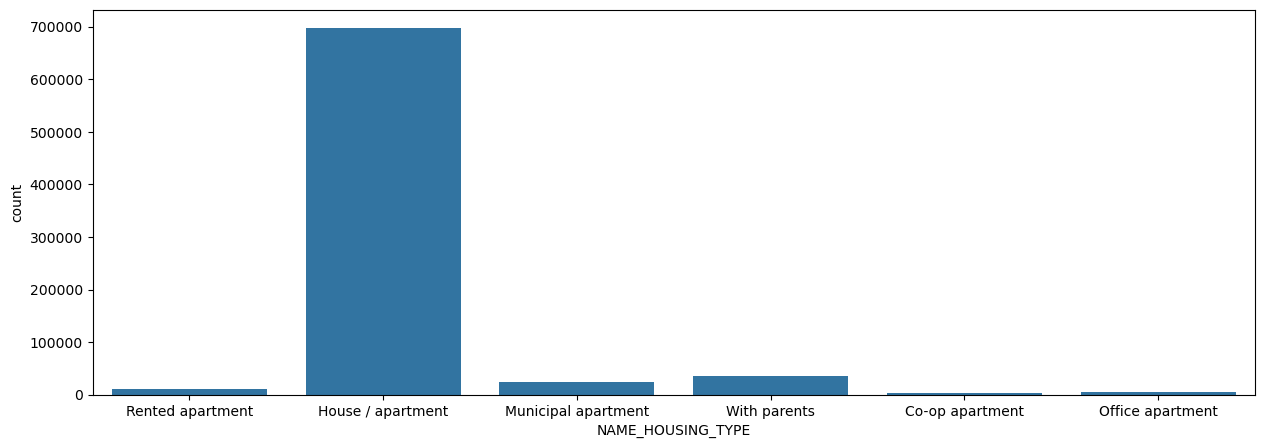

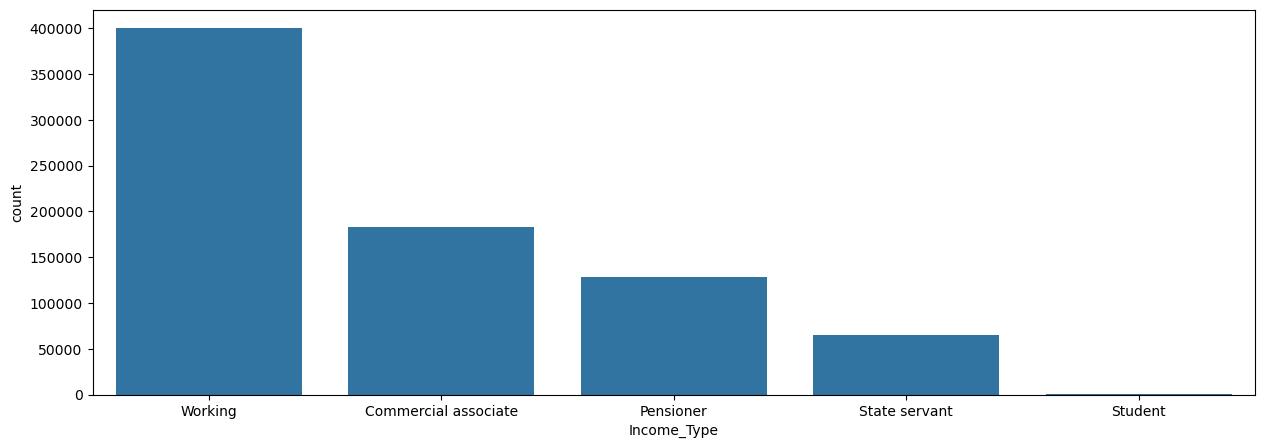

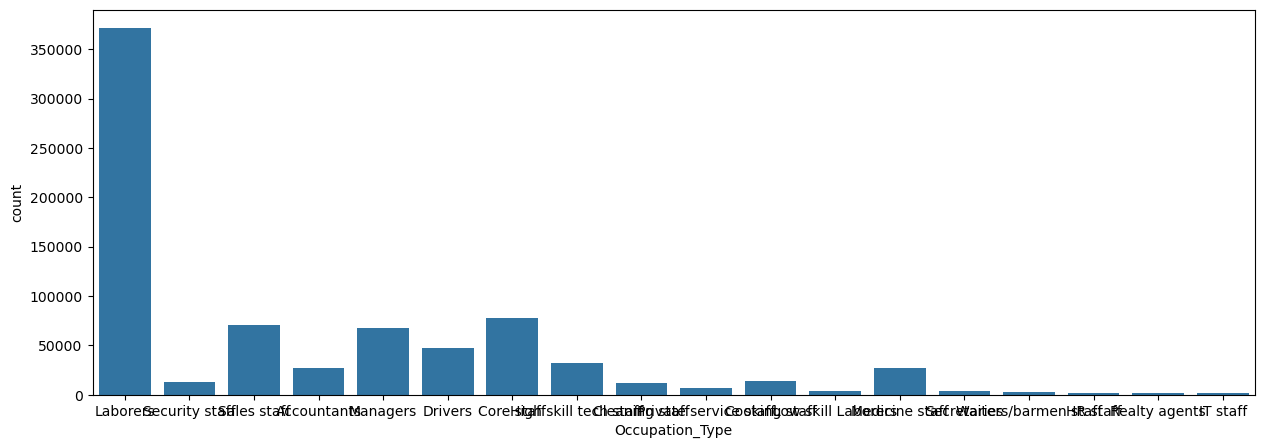

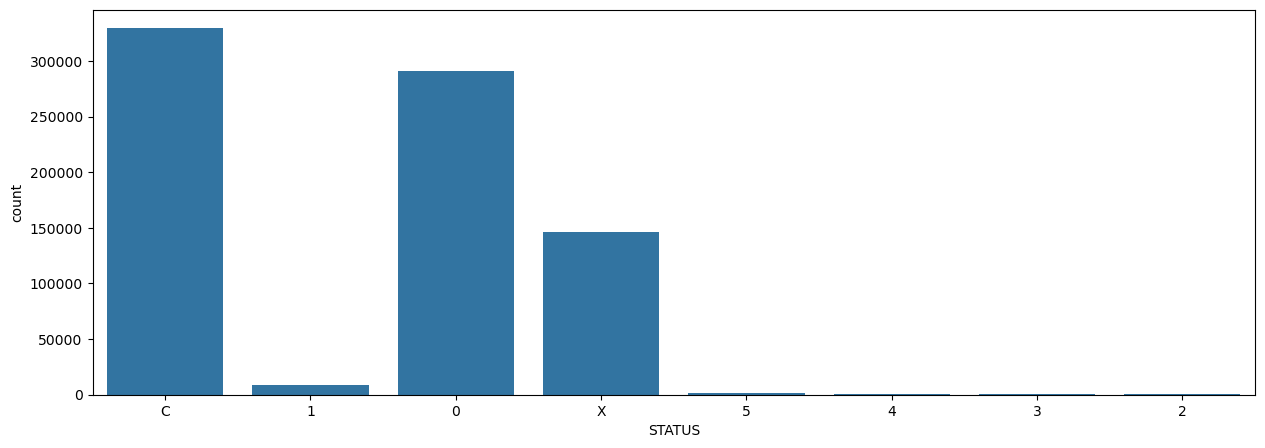

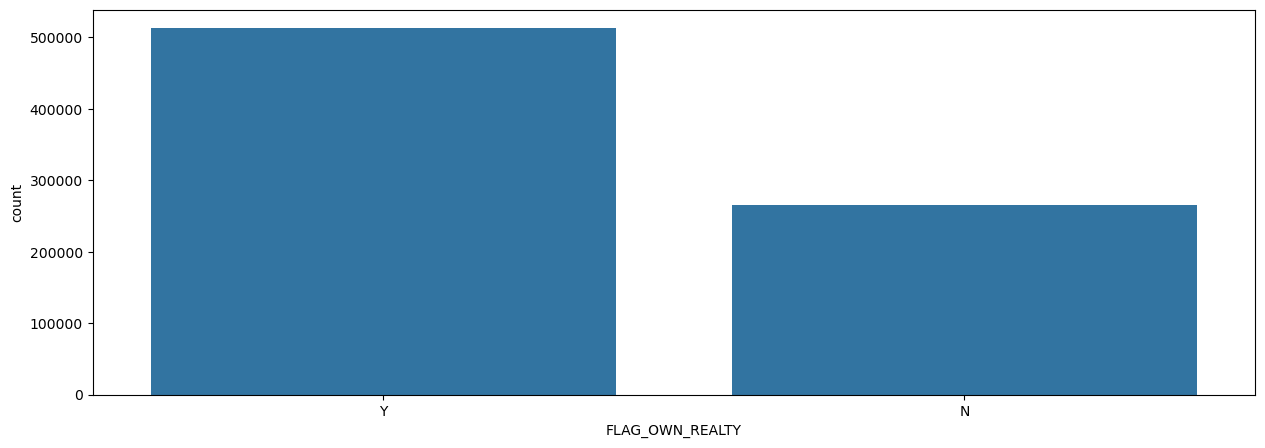

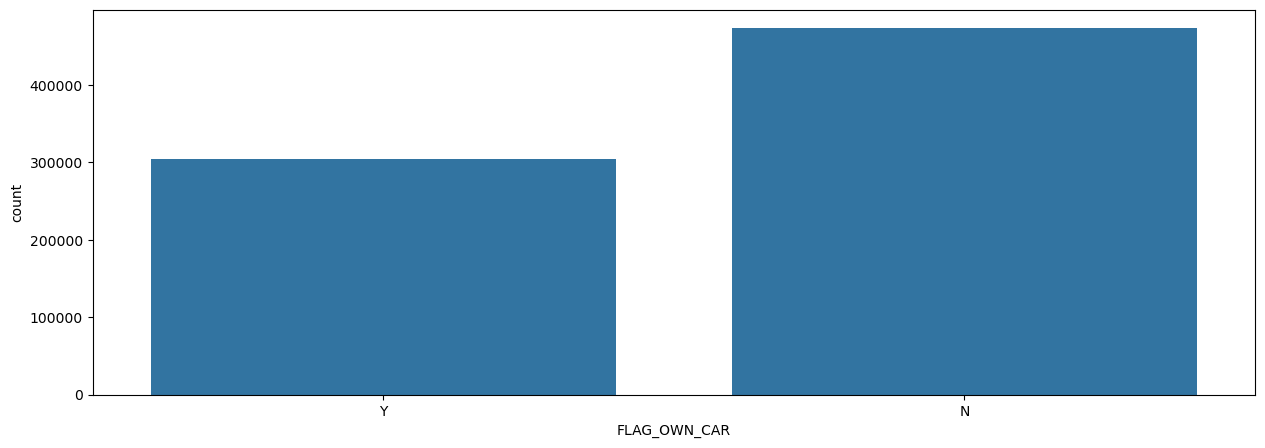

In [21]:
## 7) How are categorical features distributed?

categorical = ['CODE_GENDER','NAME_EDUCATION_TYPE','NAME_FAMILY_STATUS','NAME_HOUSING_TYPE','Income_Type',
               'Occupation_Type','STATUS','FLAG_OWN_REALTY','FLAG_OWN_CAR']

for col in categorical:
    plt.figure(figsize=[15,5])
    sb.countplot(x = df[col])
    plt.show()

The countplots show the distribution of different categorical features, where some categories have significantly higher customer counts than others.

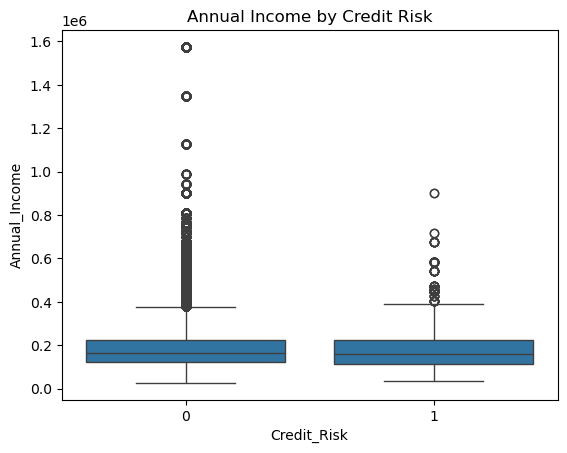

In [22]:
## 8) How does Annual Income vary between good (0) and bad (1) credit customers?

sb.boxplot(x=df.Credit_Risk , y=df.Annual_Income)
plt.title("Annual Income by Credit Risk")
plt.show()

The boxplot shows that customers with different credit risk levels have a similar income distribution, with some income outliers present in both groups.

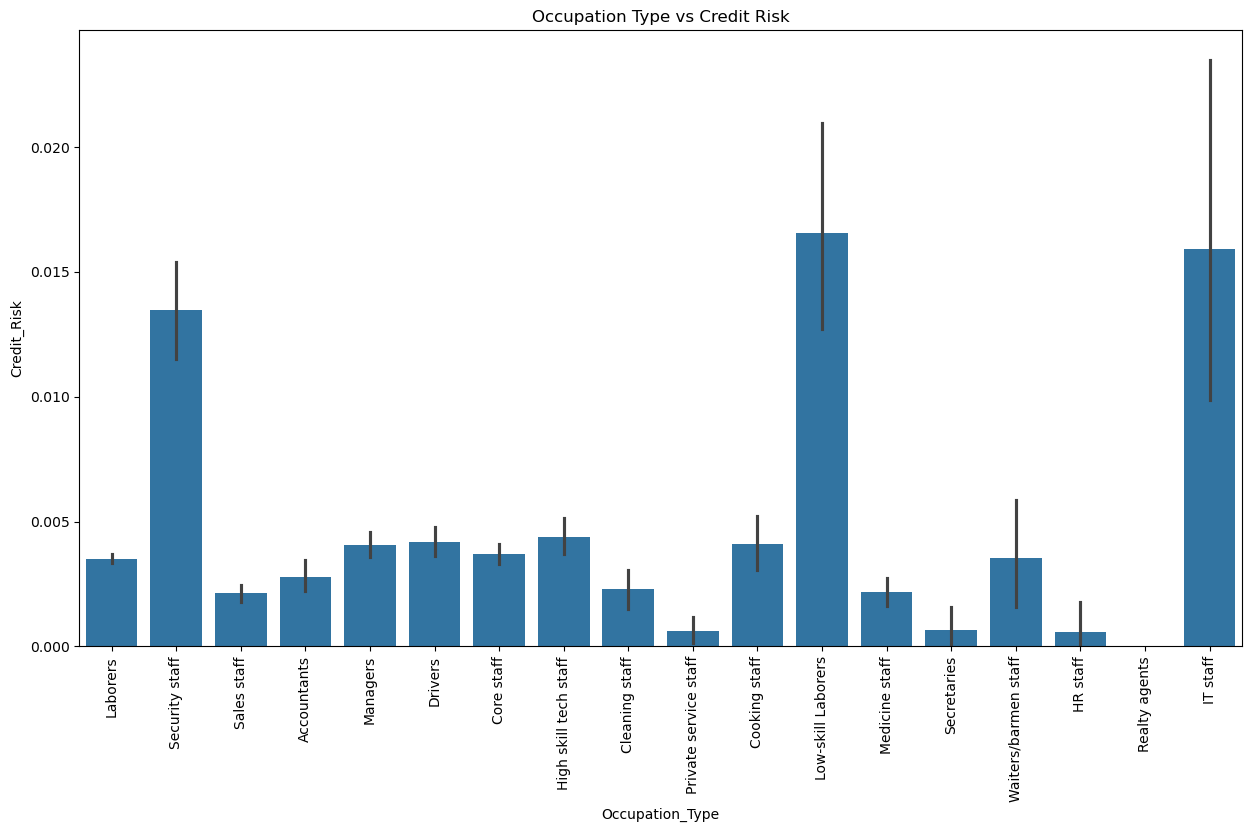

In [23]:
## 9)Are certain Occupation Types associated with higher bad credit risk?

plt.figure(figsize=[15,8])
sb.barplot(x=df.Occupation_Type , y=df.Credit_Risk)
plt.xticks(rotation=90)
plt.title("Occupation Type vs Credit Risk")
plt.show()

The barplot shows that credit risk varies across different occupation types, indicating that occupation may influence customer credit behavior.

In [24]:
## 10) What is the correlation between numerical features?

df.corr(numeric_only=True)

,ID,CNT_CHILDREN,Annual_Income,Age_Days,Employment_Days,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,Family_Member_Count,MONTHS_BALANCE,Credit_Risk
ID,1.000000,0.026269,-0.027597,-0.041938,-0.025921,NaN,0.084800,0.006346,-0.056083,0.027375,0.005007,0.010690
CNT_CHILDREN,0.026269,1.000000,0.039304,-0.356017,-0.231170,NaN,0.042226,-0.018882,0.015726,0.892079,0.000913,-0.000705
Annual_Income,-0.027597,0.039304,1.000000,-0.081093,-0.180334,NaN,-0.021229,0.018687,0.085776,0.031379,0.001831,0.003267
Age_Days,-0.041938,-0.356017,-0.081093,1.000000,0.617057,NaN,-0.181275,0.026586,-0.100706,-0.327615,-0.035813,0.005234
Employment_Days,-0.025921,-0.231170,-0.180334,0.617057,1.000000,NaN,-0.243825,-0.012788,-0.083933,-0.229471,-0.005456,0.003170
FLAG_MOBIL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_WORK_PHONE,0.084800,0.042226,-0.021229,-0.181275,-0.243825,NaN,1.000000,0.312552,-0.037991,0.060183,0.001529,0.007412
FLAG_PHONE,0.006346,-0.018882,0.018687,0.026586,-0.012788,NaN,0.312552,1.000000,0.011901,-0.007824,-0.005120,0.007213
FLAG_EMAIL,-0.056083,0.015726,0.085776,-0.100706,-0.083933,NaN,-0.037991,0.011901,1.000000,0.012540,0.005288,-0.003054
Family_Member_Count,0.027375,0.892079,0.031379,-0.327615,-0.229471,NaN,0.060183,-0.007824,0.012540,1.000000,-0.006276,-0.001874


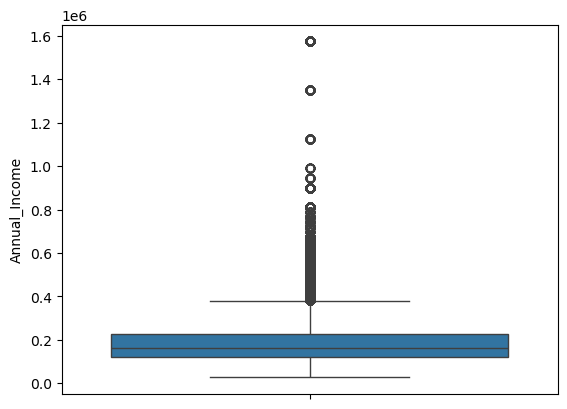

In [25]:
## 11) Are there extreme outliers in Annual Income?

sb.boxplot(df.Annual_Income)
plt.show()

The boxplot indicates the presence of several outliers in the annual income data, with most customers having income within a lower range.

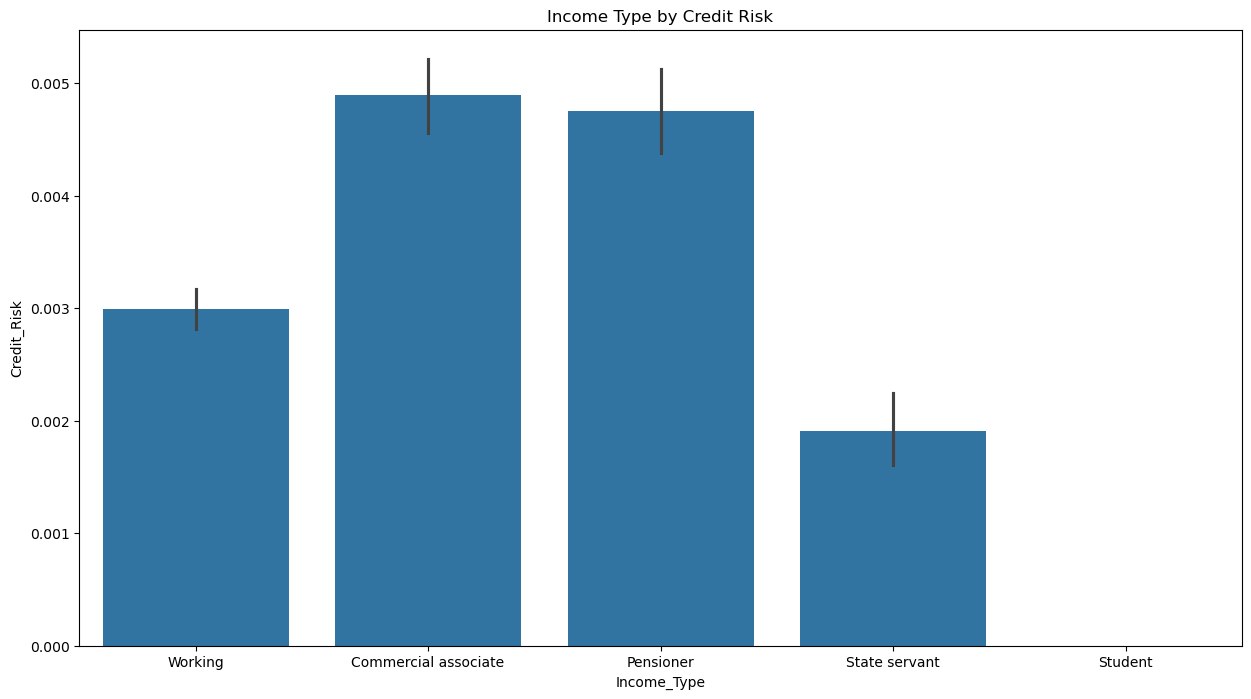

In [26]:
## 12) How does credit risk vary by Income Type?

plt.figure(figsize=[15,8])
sb.barplot(x=df.Income_Type , y=df.Credit_Risk)
plt.title("Income Type by Credit Risk")
plt.show()

The barplot shows that credit risk differs across income types, suggesting that the source of income may affect customer credit risk.

##  Phase 2 : Machine Learning Model Selection

In [27]:
df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,Annual_Income,Income_Type,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,Employment_Days,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,Occupation_Type,Family_Member_Count,MONTHS_BALANCE,STATUS,Credit_Risk
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,12,1,1,0,0,Laborers,2.0,0,C,0
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,12,1,1,0,0,Laborers,2.0,-1,C,0
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,12,1,1,0,0,Laborers,2.0,-2,C,0
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,12,1,1,0,0,Laborers,2.0,-3,C,0
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,12,1,1,0,0,Laborers,2.0,-4,C,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777710,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,...,3,1,0,0,0,Laborers,1.0,-9,0,0
777711,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,...,3,1,0,0,0,Laborers,1.0,-10,2,1
777712,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,...,3,1,0,0,0,Laborers,1.0,-11,1,0
777713,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,...,3,1,0,0,0,Laborers,1.0,-12,0,0


In [28]:
df=df.drop(['ID','STATUS','CODE_GENDER','CNT_CHILDREN','Age_Days','FLAG_MOBIL','FLAG_WORK_PHONE','FLAG_PHONE','FLAG_EMAIL'], axis=1)

In [29]:
df

,FLAG_OWN_CAR,FLAG_OWN_REALTY,Annual_Income,Income_Type,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,Employment_Days,Occupation_Type,Family_Member_Count,MONTHS_BALANCE,Credit_Risk
0,Y,Y,427500.0,Working,Higher education,Civil marriage,Rented apartment,12,Laborers,2.0,0,0
1,Y,Y,427500.0,Working,Higher education,Civil marriage,Rented apartment,12,Laborers,2.0,-1,0
2,Y,Y,427500.0,Working,Higher education,Civil marriage,Rented apartment,12,Laborers,2.0,-2,0
3,Y,Y,427500.0,Working,Higher education,Civil marriage,Rented apartment,12,Laborers,2.0,-3,0
4,Y,Y,427500.0,Working,Higher education,Civil marriage,Rented apartment,12,Laborers,2.0,-4,0
...,...,...,...,...,...,...,...,...,...,...,...,...
777710,N,Y,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,3,Laborers,1.0,-9,0
777711,N,Y,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,3,Laborers,1.0,-10,1
777712,N,Y,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,3,Laborers,1.0,-11,0
777713,N,Y,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,3,Laborers,1.0,-12,0


In [30]:
from sklearn.preprocessing import LabelEncoder
label=LabelEncoder()

In [31]:
df.FLAG_OWN_CAR=label.fit_transform(df.FLAG_OWN_CAR)
df.FLAG_OWN_REALTY=label.fit_transform(df.FLAG_OWN_REALTY)
df.Income_Type=label.fit_transform(df.Income_Type)
df.NAME_EDUCATION_TYPE=label.fit_transform(df.NAME_EDUCATION_TYPE)
df.NAME_FAMILY_STATUS=label.fit_transform(df.NAME_FAMILY_STATUS)
df.NAME_HOUSING_TYPE=label.fit_transform(df.NAME_HOUSING_TYPE)
df.Occupation_Type=label.fit_transform(df.Occupation_Type)

In [32]:
df

,FLAG_OWN_CAR,FLAG_OWN_REALTY,Annual_Income,Income_Type,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,Employment_Days,Occupation_Type,Family_Member_Count,MONTHS_BALANCE,Credit_Risk
0,1,1,427500.0,4,1,0,4,12,8,2.0,0,0
1,1,1,427500.0,4,1,0,4,12,8,2.0,-1,0
2,1,1,427500.0,4,1,0,4,12,8,2.0,-2,0
3,1,1,427500.0,4,1,0,4,12,8,2.0,-3,0
4,1,1,427500.0,4,1,0,4,12,8,2.0,-4,0
...,...,...,...,...,...,...,...,...,...,...,...,...
777710,0,1,112500.0,4,4,3,4,3,8,1.0,-9,0
777711,0,1,112500.0,4,4,3,4,3,8,1.0,-10,1
777712,0,1,112500.0,4,4,3,4,3,8,1.0,-11,0
777713,0,1,112500.0,4,4,3,4,3,8,1.0,-12,0


In [33]:
x=df.drop('Credit_Risk',axis=1).values
y=df['Credit_Risk'].values

In [34]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2)

##  Logistic Regression

In [35]:
from sklearn.linear_model import LogisticRegression
model1 = LogisticRegression() ##max_iter=1000

In [36]:
model1.fit(xtrain,ytrain)

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [37]:
ypred1 = model1.predict(xtest)
ypred1

array([0, 0, 0, ..., 0, 0, 0])

In [38]:
from sklearn.metrics import accuracy_score

In [39]:
acc2 = accuracy_score(ytest,ypred1)
acc2*100

99.65540075734684

The Logistic Regression model achieved very high accuracy (99.65%), but the convergence warning and imbalanced dataset suggest themodel may be biased toward predicting the majority class.

## Random Forest Classifier

In [40]:
from sklearn.ensemble import RandomForestClassifier
model2 = RandomForestClassifier()

In [41]:
model2.fit(xtrain,ytrain)

RandomForestClassifier()

In [42]:
ypred2 = model2.predict(xtest)
ypred2

array([0, 0, 0, ..., 0, 0, 0])

In [43]:
acc2 = accuracy_score(ytest,ypred2)
acc2*100

99.63418475919842

The Random Forest Classifier achieved very high accuracy (99.63%) and performed well in predicting credit risk, though the imbalanced dataset may still affect minority class predictions.


## XGBoost Classifier

In [46]:
from xgboost import XGBClassifier
model3 = XGBClassifier()

In [47]:
model3.fit(xtrain,ytrain)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [48]:
ypred3 = model3.predict(xtest)
ypred3

array([0, 0, 0, ..., 0, 0, 0])

In [49]:
acc3 = accuracy_score(ytest,ypred3)
acc3*100

99.68947493619127

The XGBoost Classifier achieved very high accuracy and effectively predicted credit risk, but the imbalanced dataset may still cause the model to favor the majority class.
